# 02 — `magic` 그룹 구조 심층 분석

[01 노트북](01_eda_report.ipynb) 에서 "데이터가 512개의 하위 데이터셋으로 쪼개져 있다"는 것까지 알아냈다.
이 노트북은 한 걸음 더 들어가서, **그 하위 데이터셋 하나하나가 어떻게 만들어졌는지를 역으로 추적**한다.

## 왜 생성 과정을 추적하나?

"데이터가 어떻게 만들어졌는지"를 알면 **어떤 모델이 맞을지 추측이 아니라 추론으로 정할 수 있다.**
예를 들어 데이터가 가우시안 분포에서 나왔다는 걸 알면 QDA 를,
클래스가 여러 덩어리라는 걸 알면 GMM 을 고르는 식이다.

캐글에서 이런 작업을 **"reverse engineering the data generator"** 라고 부른다.
합성 데이터 대회에서는 이게 사실상 승부처다.

## 이 노트북에서 배우는 분석 도구

| 도구 | 무엇을 재나 | 어디서 쓰나 |
|---|---|---|
| **Jaccard 유사도** | 두 집합이 얼마나 겹치나 | 1절 — train/test 구조 비교 |
| **무작위 기댓값과의 비교** | 관측값이 우연 수준인가 | 2절 — 그룹 간 공통 구조 |
| **Hanley–McNeil 표준오차** | AUC 측정값 자체의 오차 크기 | 3절 — 그룹 난이도 비교 |
| **고유값 스펙트럼** | 데이터의 진짜 차원 수 | 4절 — 중복 피처 탐지 |
| **BIC** | 몇 개의 군집이 적당한가 | 5절 — 클래스 내부 구조 |
| **카이제곱 독립성 검정** | 두 범주형 변수가 연관되나 | 6절 — GMM 군집 ↔ target |

## 다루는 질문
1. train 과 test 의 그룹 구조는 동일한가?
2. 512개 그룹은 서로 얼마나 다른가 — 공유하는 구조가 있는가?
3. **어떤 그룹이 왜 더 어려운가?**
4. 유효 피처들 사이에 중복이 있는가 — 진짜 정보 차원은 몇 개인가?
5. 클래스 하나가 몇 개의 가우시안 군집으로 이루어져 있는가?
6. 그룹 하나를 2차원으로 펼치면 어떻게 보이는가?

> ⚠️ **미리 알려둘 것:** 이 노트북에서 세운 가설 중 **두 개는 데이터에 의해 기각된다**(3절, 5절).
> 틀린 부분을 고쳐서 감추지 않고 그대로 남겨 두었다.
> 실제 EDA 는 이렇게 진행되고, **기각된 가설이 오히려 baseline 을 더 정확히 이해하게 해 준다.**

In [1]:
import gc
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

PROJECT_DIR = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "loader.py").exists()
)
sys.path.insert(0, str(PROJECT_DIR))
from data.loader import get_data_dir

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
_available = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"):
    if _font in _available:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = get_data_dir()
MAGIC_COL = "wheezy-copper-turtle-magic"
N_MAGIC = 512
STD_THRESHOLD = 2.0        # 01 노트북에서 확인한 유효 피처 판정 기준
RNG = np.random.default_rng(0)
print("data_dir:", DATA_DIR)

data_dir: C:\Users\jiho\.cache\kagglehub\competitions\original-instant-gratification


## 0. 데이터를 배열로 적재

**무엇을 하나** — DataFrame 을 numpy 배열로 바꾸고, 그룹별 행 위치를 미리 계산해 둔다.

**왜 하나** — 이 노트북은 512개 그룹을 **여러 번 반복 순회**한다.
매번 `train_df[train_df[MAGIC_COL] == m]` 을 쓰면 그때마다 262,144행을 전부 훑기 때문에
512번 × 여러 분석 = 매우 느려진다.

**최적화 두 가지**
1. **그룹 인덱스를 미리 계산** — `np.where(magic == m)[0]` 을 한 번만 계산해 딕셔너리에 저장
2. **float32 로 다운캐스트** — 메모리가 절반(510MB → 255MB)이 된다.
   float32 는 유효숫자 약 7자리라 이 노트북의 통계 계산에는 충분하다

> **초보자 팁** — EDA 코드가 느리면 분석을 덜 하게 된다.
> "이 계산을 몇 번 반복하는가"를 먼저 생각하고, 반복되는 부분을 미리 빼 두는 습관이 중요하다.

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
num_cols = [c for c in train_df.columns if c not in ("id", "target", MAGIC_COL)]

X = train_df[num_cols].to_numpy(dtype=np.float32)   # float64 -> float32 로 메모리 절반
y = train_df["target"].to_numpy()
magic = train_df[MAGIC_COL].to_numpy()

# 그룹별 행 위치를 미리 계산 (이후 모든 절에서 재사용)
group_idx = {m: np.where(magic == m)[0] for m in range(N_MAGIC)}

del train_df          # 원본 DataFrame 은 더 이상 필요 없다 (메모리 해제)
gc.collect()

print(f"X: {X.shape} ({X.nbytes / 1024**2:.0f} MB), 그룹 수: {len(group_idx)}")

# 그룹 x 피처 표준편차 행렬 (512, 255) — 01 노트북의 group_std 와 같은 것
group_std = np.vstack([X[idx].std(axis=0, ddof=1) for idx in group_idx.values()])
useful_mask = group_std > STD_THRESHOLD           # True = 그 그룹에서 신호를 가진 피처
n_useful = useful_mask.sum(axis=1)
print(f"group_std: {group_std.shape}, 그룹당 유효 피처 {n_useful.min()}~{n_useful.max()}개 (평균 {n_useful.mean():.1f})")

X: (262144, 255) (255 MB), 그룹 수: 512


group_std: (512, 255), 그룹당 유효 피처 33~47개 (평균 39.7)


## 1. train 과 test 는 같은 구조인가?

**무엇을 하나** — test 에서도 같은 방식으로 유효 피처를 뽑아, train 의 집합과 얼마나 겹치는지 잰다.

**왜 하나** — baseline 은 KernelPCA 와 GMM 을 **train + test 를 합쳐서** 적합한다.
이것을 **transductive learning(변환적 학습)** 이라 하는데,
"test 의 **정답은 모르지만 입력 피처는 볼 수 있다**"는 상황을 활용하는 방식이다.
합법이지만(대회 규칙상 test 피처는 공개되어 있다), **두 집합의 구조가 같을 때만 이득**이다.
구조가 다르면 오히려 변환이 망가진다. 그러니 쓰기 전에 확인해야 한다.

**원리 — Jaccard 유사도**
두 집합 A, B 가 얼마나 겹치는지를 재는 표준 지표.

$$ J(A,B) = \frac{|A \cap B|}{|A \cup B|} $$

- 1.0 = 완전히 같은 집합
- 0.0 = 하나도 안 겹침

**기대 결과** — 같은 생성기로 만든 데이터라면 Jaccard 가 1.0 에 가까워야 한다.
0.8 정도만 나와도 "그룹마다 쓰는 피처가 train/test 에서 다르다"는 뜻이라 transductive 는 위험해진다.

유효 피처 집합 Jaccard 유사도: 평균 1.0000, 최소 1.0000
완전히 일치하는 그룹: 512 / 512
test 그룹당 유효 피처 수 평균: 39.7


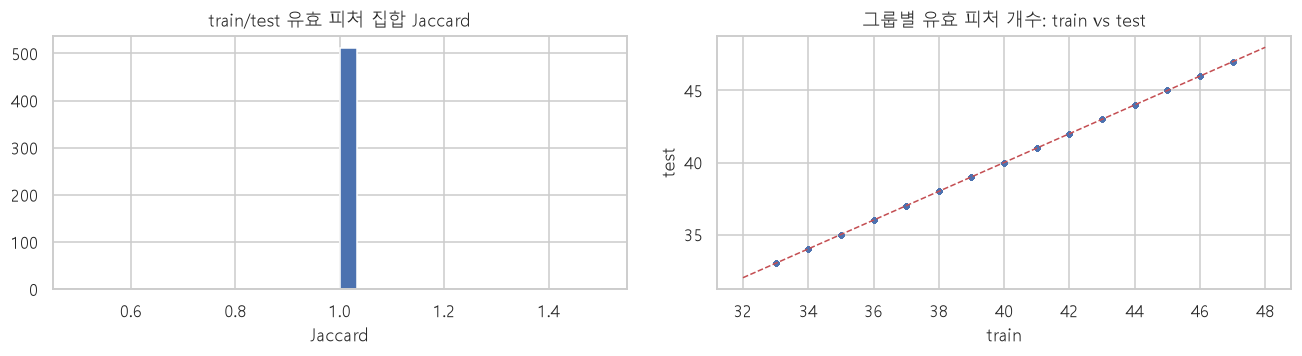

In [3]:
test_df = pd.read_csv(DATA_DIR / "public_test.csv")
Xte = test_df[num_cols].to_numpy(dtype=np.float32)
magic_te = test_df[MAGIC_COL].to_numpy()
del test_df
gc.collect()

group_idx_te = {m: np.where(magic_te == m)[0] for m in range(N_MAGIC)}
group_std_te = np.vstack([Xte[idx].std(axis=0, ddof=1) for idx in group_idx_te.values()])
useful_mask_te = group_std_te > STD_THRESHOLD

# Jaccard = 교집합 / 합집합. 불리언 배열에서는 & 와 | 로 바로 계산할 수 있다.
inter = (useful_mask & useful_mask_te).sum(axis=1)
union = (useful_mask | useful_mask_te).sum(axis=1)
jaccard = inter / union

print(f"유효 피처 집합 Jaccard 유사도: 평균 {jaccard.mean():.4f}, 최소 {jaccard.min():.4f}")
print(f"완전히 일치하는 그룹: {(jaccard == 1).sum()} / {N_MAGIC}")
print(f"test 그룹당 유효 피처 수 평균: {useful_mask_te.sum(axis=1).mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(jaccard, bins=30, color="#4c72b0")
axes[0].set_title("train/test 유효 피처 집합 Jaccard")
axes[0].set_xlabel("Jaccard")

# 산점도 + y=x 선: 점들이 선 위에 정확히 놓이면 두 집합의 크기까지 같다는 뜻
axes[1].scatter(n_useful, useful_mask_te.sum(axis=1), s=8, alpha=0.35)
lims = [n_useful.min() - 1, n_useful.max() + 1]
axes[1].plot(lims, lims, "r--", lw=1)
axes[1].set_title("그룹별 유효 피처 개수: train vs test")
axes[1].set_xlabel("train")
axes[1].set_ylabel("test")
plt.tight_layout()
plt.show()

In [4]:
# test 배열은 1절에서만 필요하다. 500MB 를 계속 들고 있을 이유가 없으니 해제한다.
del Xte, group_std_te, group_idx_te
gc.collect()
print("test 배열 해제 완료")

test 배열 해제 완료


> **관찰 1.** Jaccard 평균 **1.0000**, **512개 그룹 전부 완전 일치**.
> train 과 test 는 같은 생성기에서 나온 쌍둥이다.
>
> **결론: transductive 접근이 정당하다.** baseline 이 train+test 를 합쳐 변환을 적합하는 것은
> 근거 있는 선택이고, 실제로 이것이 성능에 가장 크게 기여한다
> ([03 노트북](03_feature_engineering.ipynb) 6절에서 +0.0169 로 측정된다).

## 2. 512개 그룹의 지문(fingerprint)

**무엇을 하나** — `useful_mask`(512 × 255 불리언 행렬)를 그림으로 그리고,
**그룹 쌍이 몇 개의 피처를 공유하는지** 센다.

**왜 하나** — 만약 그룹들이 상당수의 피처를 공유한다면,
"모든 그룹에 공통으로 쓰이는 피처"를 찾아 전역 모델을 만드는 전략이 가능하다.
공유가 없다면 그런 시도는 무의미하다. **전략의 방향이 갈리는 지점**이다.

**원리 — 무작위 기댓값과 비교하기 (EDA 의 핵심 기술)**
"두 그룹이 평균 6개의 피처를 공유한다"는 숫자만으로는 많은지 적은지 알 수 없다.
**우연히 겹칠 기댓값과 비교**해야 한다.

각 그룹이 255개 중 40개를 무작위로 고른다면, 두 그룹의 기대 공유 개수는

$$ E[|A \cap B|] = \frac{|A| \times |B|}{255} \approx \frac{40 \times 40}{255} \approx 6.3 $$

(A 의 각 원소가 B 에 속할 확률이 |B|/255 이므로, 이를 |A|번 더한 값)

**기대 결과 (가설)** — 만약 관측값이 기댓값과 **같다**면 → 그룹별 피처 선택은 완전 무작위.
관측값이 **크다**면 → 자주 쓰이는 "인기 피처"가 있다는 뜻이고 공통 구조를 노려볼 수 있다.

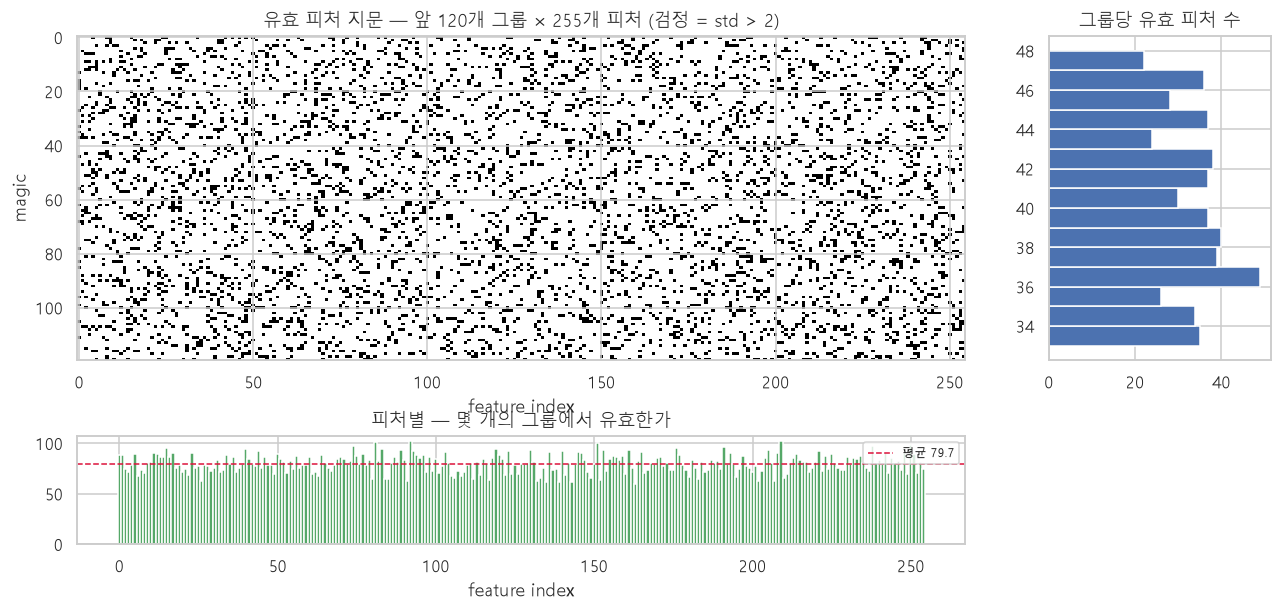

피처가 유효한 그룹 수: 최소 60, 최대 102, 평균 79.7
512개 그룹 × 평균 39.7개 / 255개 피처 = 79.7 (일치)


In [5]:
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[3, 1], hspace=0.35, wspace=0.15)

# 메인: 이진 행렬을 그대로 이미지로 (검정 = 그 그룹에서 유효한 피처)
ax_main = fig.add_subplot(gs[0, 0])
ax_main.imshow(useful_mask[:120], aspect="auto", cmap="Greys", interpolation="nearest")
ax_main.set_title("유효 피처 지문 — 앞 120개 그룹 × 255개 피처 (검정 = std > 2)")
ax_main.set_xlabel("feature index")
ax_main.set_ylabel("magic")

# 오른쪽: 행 방향 합계 = 그룹당 유효 피처 수
ax_right = fig.add_subplot(gs[0, 1])
ax_right.hist(n_useful, bins=range(n_useful.min(), n_useful.max() + 2),
              orientation="horizontal", color="#4c72b0")
ax_right.set_title("그룹당 유효 피처 수")

# 아래: 열 방향 합계 = 피처별로 몇 개 그룹에서 쓰이나
ax_bottom = fig.add_subplot(gs[1, 0])
times_useful = useful_mask.sum(axis=0)
ax_bottom.bar(np.arange(len(times_useful)), times_useful, width=1.0, color="#55a868")
ax_bottom.axhline(times_useful.mean(), color="crimson", ls="--", lw=1,
                  label=f"평균 {times_useful.mean():.1f}")
ax_bottom.set_title("피처별 — 몇 개의 그룹에서 유효한가")
ax_bottom.set_xlabel("feature index")
ax_bottom.legend(fontsize=8)
plt.show()

print(f"피처가 유효한 그룹 수: 최소 {times_useful.min()}, 최대 {times_useful.max()}, 평균 {times_useful.mean():.1f}")
# 검산: 전체 True 개수를 두 방향으로 세면 같아야 한다
print(f"512개 그룹 × 평균 {n_useful.mean():.1f}개 / 255개 피처 = {n_useful.sum() / 255:.1f} (일치)")

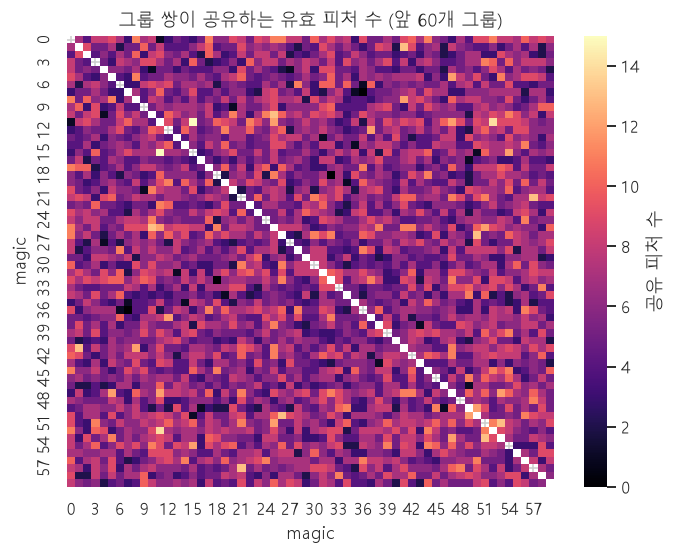

관측 평균 공유 피처 수: 6.17
무작위 선택 가정 시 기댓값: 6.17  ->  그룹별 피처 선택은 사실상 독립·무작위


In [6]:
# 그룹 쌍이 공유하는 유효 피처 수를 한 번에 계산하는 요령:
# 불리언 행렬 S (그룹 x 피처) 에 대해 S @ S.T 의 (i,j) 원소가 곧 i,j 가 공유하는 피처 수다.
sub = useful_mask[:60].astype(float)
overlap = sub @ sub.T
np.fill_diagonal(overlap, np.nan)   # 자기 자신과의 비교는 의미 없으므로 제외

plt.figure(figsize=(6.4, 5.2))
sns.heatmap(overlap, cmap="magma", cbar_kws={"label": "공유 피처 수"})
plt.title("그룹 쌍이 공유하는 유효 피처 수 (앞 60개 그룹)")
plt.xlabel("magic")
plt.ylabel("magic")
plt.tight_layout()
plt.show()

off = overlap[~np.isnan(overlap)]
expected = n_useful.mean() ** 2 / 255      # 무작위로 골랐을 때의 기대 공유 개수
print(f"관측 평균 공유 피처 수: {off.mean():.2f}")
print(f"무작위 선택 가정 시 기댓값: {expected:.2f}  ->  그룹별 피처 선택은 사실상 독립·무작위")

> **관찰 2.** 관측 평균 **6.17** vs 무작위 기댓값 **6.17** — 소수점 둘째 자리까지 일치한다.
> 히트맵에도 밝은 줄무늬(= 인기 그룹/피처)가 전혀 없다.
>
> **결론: 512개 그룹은 255개 피처 중 40개 남짓을 매번 독립적으로 무작위 추출해 만든
> 별개의 데이터셋이다.** 그룹 간에 재사용할 공통 구조가 없으므로,
> 전체 데이터를 한 번에 학습하는 접근은 원리적으로 실패한다.
> 이것이 01 노트북에서 단일 피처 AUC 가 0.5 였던 이유의 완전한 설명이다.
>
> **여기서 배울 점:** "평균 6개 공유"라는 숫자 하나는 아무 정보가 없었다.
> **기댓값이라는 비교 대상**을 만들었을 때 비로소 결론이 나왔다.

## 3. 그룹 난이도 — 어떤 그룹이 왜 더 어려운가?

**무엇을 하나** — 512개 그룹 각각에 **QDA 5-fold OOF AUC** 를 재고,
그 차이를 **유효 피처 개수**로 설명할 수 있는지 본다.

**왜 하나** — 만약 그룹마다 난이도가 정말 다르다면
"어려운 그룹에는 다른 모델을 쓴다" 같은 전략이 가능해진다. **전략 판단을 위한 측정**이다.

**용어 — OOF (Out-Of-Fold)**
데이터를 K개로 나눠서, 각 조각을 예측할 때는 **그 조각을 빼고 학습한 모델**을 쓴다.
이렇게 모은 예측이 OOF 예측이다. 모든 행에 대해 "학습에 쓰이지 않은 상태의 예측"을 갖게 되므로
**정직한 성능 추정**이 된다. 캐글에서 CV 점수라고 하면 대개 이것이다.

**가설** — 유효 피처가 많을수록 어려울 것이다.
학습 표본은 512행으로 고정인데 QDA 가 추정해야 할 공분산 원소는 차원의 제곱으로 늘어나기 때문이다
(40차원이면 클래스당 40×41/2 = 820개를 256개 표본으로 추정해야 한다).

**기대 결과** — 유효 피처 수와 AUC 사이에 **뚜렷한 음의 상관**.

In [7]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm


def group_qda_auc(magic_value, reg_param=0.111, n_splits=5, seed=0):
    """한 magic 그룹의 QDA 5-fold OOF AUC.

    QDA 는 baseline 6개 모델 중 학습이 가장 가벼워서 512번 반복해도 빠르다.
    그룹 난이도의 대리 지표로 쓴다.
    """
    idx = group_idx[magic_value]
    cols = np.where(useful_mask[magic_value])[0]      # 그 그룹의 유효 피처만 사용
    Xg = StandardScaler().fit_transform(X[np.ix_(idx, cols)])
    yg = y[idx]

    oof = np.zeros(len(idx))
    # StratifiedKFold: 각 fold 의 클래스 비율을 원본과 같게 유지하며 분할
    for trn, val in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(Xg, yg):
        model = QuadraticDiscriminantAnalysis(reg_param=reg_param).fit(Xg[trn], yg[trn])
        oof[val] = model.predict_proba(Xg[val])[:, 1]  # 학습에 안 쓰인 조각만 예측
    return roc_auc_score(yg, oof), oof


group_auc = np.zeros(N_MAGIC)
for m in tqdm(range(N_MAGIC), desc="group QDA"):
    group_auc[m], _ = group_qda_auc(m)

print(f"그룹별 QDA AUC — 평균 {group_auc.mean():.4f}, 표준편차 {group_auc.std():.4f}")
print(f"최저 {group_auc.min():.4f} (magic={group_auc.argmin()}), 최고 {group_auc.max():.4f} (magic={group_auc.argmax()})")

group QDA:   0%|          | 0/512 [00:00<?, ?it/s]

그룹별 QDA AUC — 평균 0.9362, 표준편차 0.0124
최저 0.8956 (magic=92), 최고 0.9662 (magic=55)


그룹별 AUC 가 0.896 ~ 0.966 까지 벌어졌다. 언뜻 "쉬운 그룹과 어려운 그룹이 확실히 있다"로 보인다.

**하지만 여기서 한 번 멈춰야 한다.** 각 AUC 는 **512행에서 잰 값**이다.
표본이 적으면 측정값 자체가 흔들리므로, **차이가 진짜인지 측정 오차인지 구분**해야 한다.

**원리 — Hanley–McNeil 표준오차**
AUC 추정치가 표본 때문에 얼마나 흔들리는지 계산하는 고전적인 공식이다.
양성 n₁개, 음성 n₂개로 잰 AUC(=A)의 분산은

$$ \mathrm{Var}(A) = \frac{A(1-A) + (n_1-1)(Q_1 - A^2) + (n_2-1)(Q_2 - A^2)}{n_1 n_2} $$

$$ Q_1 = \frac{A}{2-A}, \qquad Q_2 = \frac{2A^2}{1+A} $$

**분산 분해 — 이 절의 핵심 아이디어**

$$ \text{관측된 흩어짐}^2 = \text{진짜 그룹 차이}^2 + \text{측정 오차}^2 $$

이므로, 관측 분산에서 측정 오차 분산을 **빼면** 진짜 그룹 차이를 얻을 수 있다.
이 사고방식은 통계에서 매우 널리 쓰인다(측정 오차 보정).

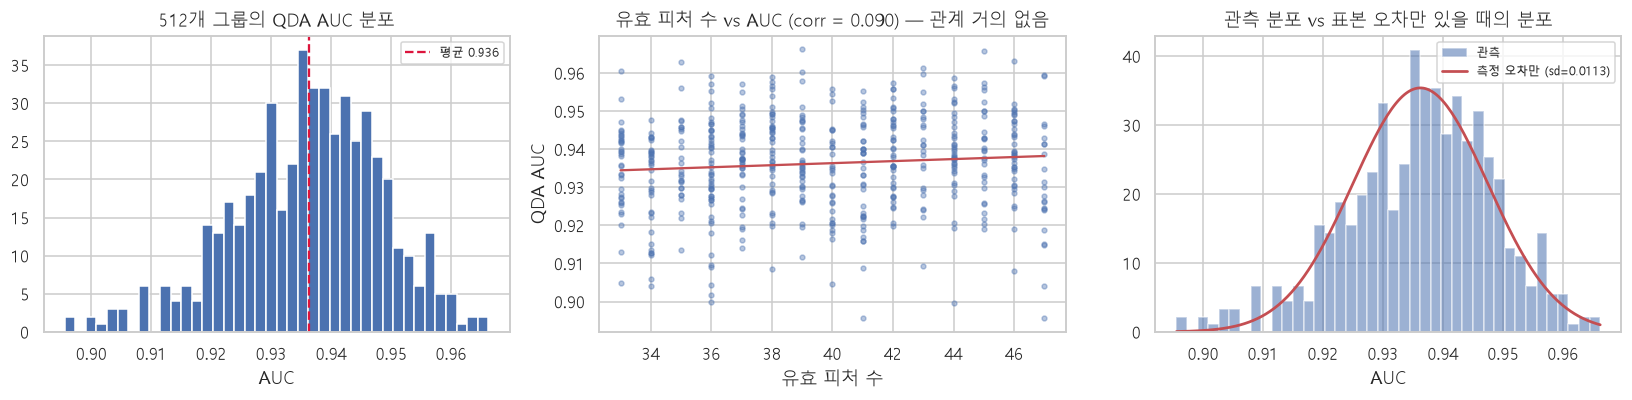

피어슨 상관(유효 피처 수 vs AUC): 0.0904  (기울기 0.00027 AUC / 피처 1개)
  -> 유효 피처가 14개(33->47) 늘어도 AUC 변화는 +0.0037 에 불과

관측된 그룹 간 AUC 표준편차 : 0.0124
512행 표본에서 오는 측정 오차 : 0.0113  (Hanley-McNeil)
차감한 '진짜' 그룹 간 편차   : 0.0051  (관측 분산의 17%)


In [8]:
def hanley_mcneil_se(auc, n_pos, n_neg):
    """AUC 추정치의 표본 오차 (Hanley & McNeil, 1982).

    같은 모델·같은 분포라도 표본이 512행뿐이면 AUC 는 이 정도씩 흔들린다.
    """
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    var = (
        auc * (1 - auc)
        + (n_pos - 1) * (q1 - auc**2)
        + (n_neg - 1) * (q2 - auc**2)
    ) / (n_pos * n_neg)
    return np.sqrt(var)


n_pos = np.array([y[group_idx[m]].sum() for m in range(N_MAGIC)])
n_neg = np.array([len(group_idx[m]) for m in range(N_MAGIC)]) - n_pos
se_group = hanley_mcneil_se(group_auc, n_pos, n_neg)

# 분산 분해: 관측 분산 = 진짜 차이 분산 + 측정 오차 분산
observed_sd = group_auc.std()
noise_sd = np.sqrt((se_group**2).mean())
true_sd = np.sqrt(max(observed_sd**2 - noise_sd**2, 0))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

axes[0].hist(group_auc, bins=40, color="#4c72b0")
axes[0].axvline(group_auc.mean(), color="crimson", ls="--", label=f"평균 {group_auc.mean():.3f}")
axes[0].set_title("512개 그룹의 QDA AUC 분포")
axes[0].set_xlabel("AUC")
axes[0].legend(fontsize=8)

axes[1].scatter(n_useful, group_auc, s=10, alpha=0.4)
fit = np.polyfit(n_useful, group_auc, 1)          # 1차 회귀선
xs = np.array([n_useful.min(), n_useful.max()])
axes[1].plot(xs, np.polyval(fit, xs), "r-", lw=1.5)
corr = np.corrcoef(n_useful, group_auc)[0, 1]
axes[1].set_title(f"유효 피처 수 vs AUC (corr = {corr:.3f}) — 관계 거의 없음")
axes[1].set_xlabel("유효 피처 수")
axes[1].set_ylabel("QDA AUC")

# 관측 분포와 "측정 오차만 있을 때 예상되는 분포"를 겹쳐 그린다
grid = np.linspace(group_auc.min(), group_auc.max(), 200)
axes[2].hist(group_auc, bins=40, density=True, color="#4c72b0", alpha=0.55, label="관측")
null_pdf = np.exp(-0.5 * ((grid - group_auc.mean()) / noise_sd) ** 2) / (noise_sd * np.sqrt(2 * np.pi))
axes[2].plot(grid, null_pdf, "r-", lw=1.8, label=f"측정 오차만 (sd={noise_sd:.4f})")
axes[2].set_title("관측 분포 vs 표본 오차만 있을 때의 분포")
axes[2].set_xlabel("AUC")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"피어슨 상관(유효 피처 수 vs AUC): {corr:.4f}  (기울기 {fit[0]:.5f} AUC / 피처 1개)")
print(f"  -> 유효 피처가 14개(33->47) 늘어도 AUC 변화는 {fit[0] * 14:+.4f} 에 불과")
print()
print(f"관측된 그룹 간 AUC 표준편차 : {observed_sd:.4f}")
print(f"512행 표본에서 오는 측정 오차 : {noise_sd:.4f}  (Hanley-McNeil)")
print(f"차감한 '진짜' 그룹 간 편차   : {true_sd:.4f}  (관측 분산의 {true_sd**2 / observed_sd**2:.0%})")

> ### ❌ 가설 기각 #1
>
> 세운 가설은 "유효 피처가 많을수록 차원-표본 비가 나빠져 AUC 가 떨어진다" 였다.
> 실제 상관은 **+0.09 로 사실상 무관**이다. 유효 피처가 33개에서 47개로 늘어도
> AUC 변화는 +0.004 수준이다. **가설은 틀렸다.**
>
> 더 중요한 것은 세 번째 그림이다. 관측된 분포(파란 히스토그램)와
> "측정 오차만 있을 때 예상되는 분포"(빨간 곡선)가 거의 포개진다.
> 분산 분해를 하면 **관측된 흩어짐의 83%가 측정 오차**이고,
> 진짜 그룹 간 차이는 표준편차 0.0051 에 불과하다.
>
> **즉 "어려운 그룹"은 대부분 착시다.** magic=92 의 AUC 0.906 은
> 그 그룹이 정말 어려워서가 아니라, 512행으로 재다 보니 낮게 나온 쪽에 속했을 뿐이다.
>
> ### 실무적 함의 (이게 진짜 수확이다)
>
> 1. **그룹별로 모델이나 하이퍼파라미터를 다르게 가져갈 근거가 약하다.**
>    512개 그룹에 같은 파이프라인을 적용하는 baseline 의 선택이 옳다.
>    ([04 노트북](04_model_diagnostics.ipynb) 4절에서 이 결론을 다시 확인한다)
> 2. **개별 그룹 점수에 반응해 튜닝하면 잡음을 학습한다.**
>    "magic=92 가 유독 낮으니 여기만 손보자"는 전형적인 함정이다.
>
> > **초보자에게** — 캐글에서 가장 흔한 실수가 **잡음을 신호로 착각한 튜닝**이다.
> > 어떤 숫자를 보고 행동하기 전에 항상 물어보라: **"이 차이가 측정 오차보다 큰가?"**

## 4. 유효 피처 안에 중복이 있는가 — 진짜 정보 차원

**무엇을 하나** — 그룹의 공분산 행렬의 **고유값**을 크기 순으로 늘어놓는다.

**왜 하나** — 차원 축소(PCA)를 해도 되는지 판단하기 위해서다.
01 노트북 6절에서 상관계수로 한 번 봤는데, 여기서는 더 확실한 방법으로 확인한다.

**원리 — `make_classification` 의 피처 종류**
sklearn 의 합성 데이터 생성기는 세 종류의 피처를 만든다.
- `n_informative`: 진짜 정보를 담은 독립 차원
- `n_redundant`: informative 의 **선형결합** (정보 중복)
- `n_repeated`: 그냥 **복사본**

**원리 — 고유값 스펙트럼으로 중복 탐지하기**
공분산 행렬의 고유값은 "각 방향으로 데이터가 얼마나 퍼져 있는가"다.
- redundant 피처가 있으면 → 어떤 방향은 데이터가 **전혀 퍼지지 않는다**(선형 종속)
  → 고유값이 **0에 가까워지고**, 스펙트럼에 **절벽/계단**이 생긴다
- 모든 피처가 독립이면 → 고유값이 완만하게 감소하고 0인 것이 없다 (**full rank**)

**기대 결과 (두 갈래)**
- 계단이 보인다 → 중복 있음 → **PCA 로 차원을 줄여도 정보 손실이 없다**
- 계단이 없다 → 중복 없음 → **차원을 줄이면 그만큼 정보가 사라진다**

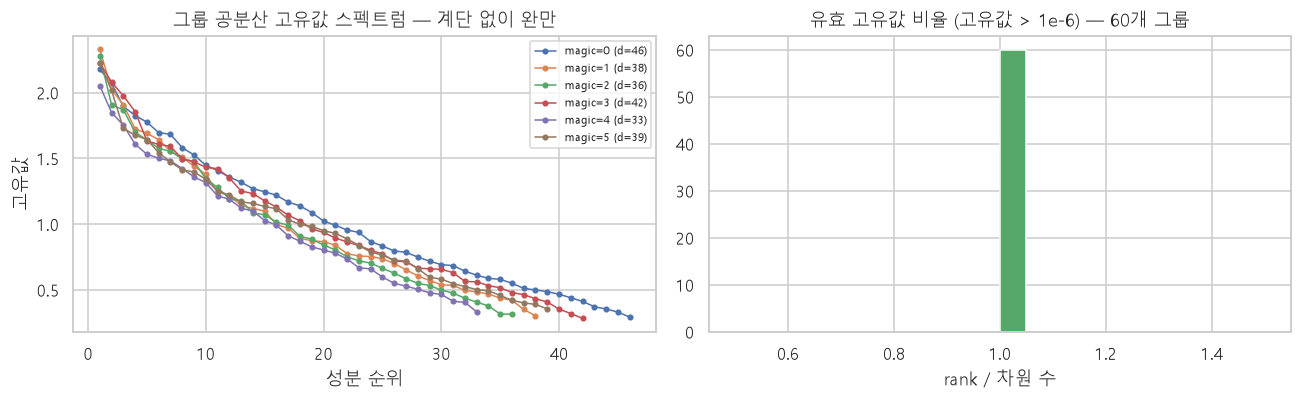

유효 고유값 비율: 평균 1.0000 (1.0 이면 중복 피처 없음)


In [9]:
def eigen_spectrum(magic_value):
    """한 그룹의 공분산 행렬 고유값을 큰 것부터 정렬해 반환."""
    idx = group_idx[magic_value]
    cols = np.where(useful_mask[magic_value])[0]
    Xg = StandardScaler().fit_transform(X[np.ix_(idx, cols)])
    # eigvalsh: 대칭 행렬 전용 고유값 계산 (공분산은 항상 대칭이라 더 빠르고 안정적)
    return np.linalg.eigvalsh(np.cov(Xg, rowvar=False))[::-1]


sample_magics = [0, 1, 2, 3, 4, 5]
plt.figure(figsize=(12, 3.8))
plt.subplot(1, 2, 1)
for m in sample_magics:
    ev = eigen_spectrum(m)
    plt.plot(np.arange(1, len(ev) + 1), ev, marker="o", ms=3, lw=1, label=f"magic={m} (d={len(ev)})")
plt.title("그룹 공분산 고유값 스펙트럼 — 계단 없이 완만")
plt.xlabel("성분 순위")
plt.ylabel("고유값")
plt.legend(fontsize=7)

plt.subplot(1, 2, 2)
ranks = []
for m in range(60):
    ev = eigen_spectrum(m)
    ranks.append((ev > 1e-6).sum() / len(ev))   # 0이 아닌 고유값 비율 = rank 비율
plt.hist(ranks, bins=20, color="#55a868")
plt.title("유효 고유값 비율 (고유값 > 1e-6) — 60개 그룹")
plt.xlabel("rank / 차원 수")
plt.tight_layout()
plt.show()

print(f"유효 고유값 비율: 평균 {np.mean(ranks):.4f} (1.0 이면 중복 피처 없음)")

> **관찰 4.** 고유값 비율 **1.0000** — 공분산 행렬이 full rank 이고 스펙트럼에 계단이 없다.
> **redundant / repeated 피처는 없고, 유효 피처 ≈ informative 차원**이다.
>
> **결론: 차원 축소는 정보 손실이다.**
> 그래서 baseline 의 `KernelPCA(n_components=len(cols))` 는
> **차원을 유지한 채 좌표계만 바꾸는** 용도로 이해해야 한다. 줄이는 게 목적이 아니다.
>
> 이 예측은 [03 노트북](03_feature_engineering.ipynb) 3절에서 실제로 차원을 줄여 보며 검증한다
> (75%로만 줄여도 AUC 가 0.008 떨어진다).

## 5. 클래스 하나는 몇 개의 군집으로 이루어졌는가

**무엇을 하나** — 클래스별로 GMM 의 군집 수 k 를 1~8 로 바꿔 가며 **BIC** 를 비교한다.

**왜 하나** — baseline 은 `GaussianMixture(n_components=5)` 를 쓴다.
**왜 하필 5인가?** 데이터에 정말 5개의 군집이 있어서인지 확인해 보자는 것이다.

**용어 — GMM (Gaussian Mixture Model)**
데이터가 여러 개의 가우시안 분포가 섞인 것이라고 보고,
각 가우시안의 중심·퍼짐·비중을 추정하는 모델. 군집화에 쓰인다.

**용어 — BIC (Bayesian Information Criterion)**

$$ \mathrm{BIC} = -2 \ln(\text{우도}) + (\text{파라미터 수}) \times \ln(\text{표본 수}) $$

모델이 데이터를 잘 설명할수록 첫 항이 작아지고, 복잡할수록 둘째 항이 커진다.
**BIC 가 가장 낮은 모델이 "설명력 대비 가장 간결한" 모델**이다.
군집 수를 늘리면 항상 데이터는 더 잘 맞지만(과적합), BIC 는 그 대가를 물린다.

**설계상의 주의점 두 가지**
1. **차원을 줄여야 한다** — 40차원에서 full 공분산 GMM 은 군집당 820개 파라미터가 필요한데
   클래스당 표본은 256개뿐이다. 그래서 PCA 로 10차원까지 줄여서 본다
2. **여러 그룹을 평균낸다** — 그룹 하나로는 잡음이 크므로 24개 그룹의 BIC 곡선을
   0~1 로 정규화해서 평균낸다 (3절에서 배운 교훈의 적용)

**가설** — 이 데이터는 클래스마다 여러 군집으로 이루어져 있을 것이다(그래야 QDA·GMM 이 잘 통하는 게 설명된다).
**기대 결과** — BIC 곡선의 최솟값이 k > 1 에서 나타날 것.

BIC:   0%|          | 0/24 [00:00<?, ?it/s]

[full] target=0: 평균 BIC 최소 k = 1, 그룹별 최빈 k = 1
[full] target=1: 평균 BIC 최소 k = 1, 그룹별 최빈 k = 1
[diag] target=0: 평균 BIC 최소 k = 1, 그룹별 최빈 k = 1
[diag] target=1: 평균 BIC 최소 k = 1, 그룹별 최빈 k = 1


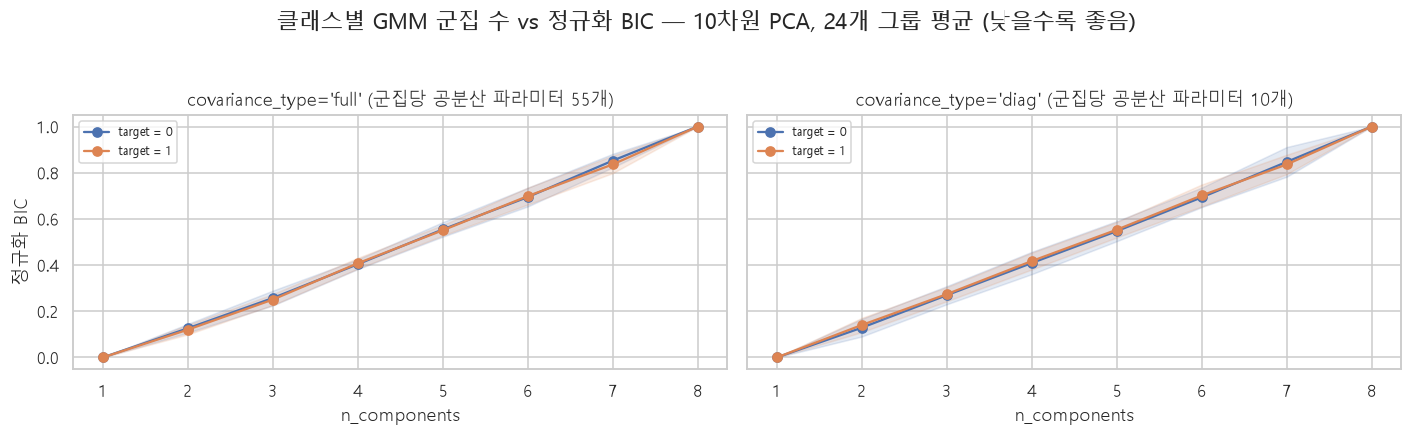


참고: 클래스당 표본은 256행뿐이다.
  full: k=2 로 늘리면 파라미터가 65개 -> 131개로 증가
  diag: k=2 로 늘리면 파라미터가 20개 -> 41개로 증가


In [10]:
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

K_RANGE = np.arange(1, 9)
BIC_MAGICS = list(range(24))
# covariance_type 에 따라 파라미터 수가 크게 달라진다.
#   full: 군집당 d(d+1)/2 개 (10차원이면 55개)  -> 벌점이 크다
#   diag: 군집당 d 개 (10차원이면 10개)         -> 벌점이 작다
# 한쪽만 보면 "벌점 때문에 k=1 이 나온 것"인지 알 수 없으므로 둘 다 본다.
bic_curves = {("full", 0): [], ("full", 1): [], ("diag", 0): [], ("diag", 1): []}

for m in tqdm(BIC_MAGICS, desc="BIC"):
    idx = group_idx[m]
    cols = np.where(useful_mask[m])[0]
    Xg = StandardScaler().fit_transform(X[np.ix_(idx, cols)])
    Xp = PCA(n_components=10, random_state=0).fit_transform(Xg)   # 40차원 -> 10차원
    yg = y[idx]
    for cov_type in ("full", "diag"):
        for cls in (0, 1):
            Xc = Xp[yg == cls]                 # 클래스별로 따로 적합
            bics = np.array([
                GaussianMixture(n_components=k, covariance_type=cov_type, random_state=0,
                                max_iter=500, reg_covar=1e-3).fit(Xc).bic(Xc)
                for k in K_RANGE
            ])
            # 그룹마다 BIC 의 절대 크기가 달라서 그대로 평균내면 큰 그룹이 지배한다.
            # 0~1 로 정규화한 뒤 평균내야 '모양'을 비교할 수 있다.
            bic_curves[(cov_type, cls)].append((bics - bics.min()) / (bics.max() - bics.min()))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, cov_type in zip(axes, ("full", "diag")):
    n_params = {"full": 10 * 11 // 2, "diag": 10}[cov_type]
    for cls, color in zip((0, 1), ("#4c72b0", "#dd8452")):
        curves = np.vstack(bic_curves[(cov_type, cls)])
        mean, std = curves.mean(axis=0), curves.std(axis=0)
        ax.plot(K_RANGE, mean, marker="o", color=color, label=f"target = {cls}")
        ax.fill_between(K_RANGE, mean - std, mean + std, color=color, alpha=0.15)
        best = K_RANGE[mean.argmin()]
        vote = np.bincount(curves.argmin(axis=1) + 1, minlength=9).argmax()
        print(f"[{cov_type:4s}] target={cls}: 평균 BIC 최소 k = {best}, 그룹별 최빈 k = {vote}")
    ax.set_title(f"covariance_type='{cov_type}' (군집당 공분산 파라미터 {n_params}개)")
    ax.set_xlabel("n_components")
    ax.legend(fontsize=8)
axes[0].set_ylabel("정규화 BIC")
fig.suptitle(f"클래스별 GMM 군집 수 vs 정규화 BIC — 10차원 PCA, {len(BIC_MAGICS)}개 그룹 평균 (낮을수록 좋음)", y=1.04)
plt.tight_layout()
plt.show()

print()
print("참고: 클래스당 표본은 256행뿐이다.")
print(f"  full: k=2 로 늘리면 파라미터가 {10 + 55}개 -> {2 * (10 + 55) + 1}개로 증가")
print(f"  diag: k=2 로 늘리면 파라미터가 {10 + 10}개 -> {2 * (10 + 10) + 1}개로 증가")

> ### ❌ 가설 기각 #2
>
> BIC 는 **두 covariance_type 모두에서 k = 1** 을 고른다. 벌점이 작은 diag 에서도 마찬가지다.
> 즉 벌점 크기 탓으로 돌릴 수 없다.
>
> **정확한 결론은 "군집이 하나다"가 아니라 "클래스당 256개 표본으로는 다봉 구조를
> 밀도 모형으로 식별할 수 없다"** 이다. 이 둘은 다르다.
> 없다는 증거가 아니라, 있더라도 이 표본 수로는 BIC 를 이길 만큼 증거가 모이지 않는다는 뜻이다.
>
> ### 그런데 이 기각이 baseline 해석을 바꾼다 (중요)
>
> BIC 가 k=1 을 고르는데 baseline 은 k=5 를 쓴다. 그럼 baseline 이 틀린 걸까?
> **아니다. GMM 을 쓰는 목적이 다르다.**
>
> | GMM 을 보는 관점 | 좋은 k 를 고르는 기준 |
> |---|---|
> | **밀도 추정기** — 데이터의 진짜 분포를 설명 | BIC / AIC → 여기서는 k=1 |
> | **피처 생성기** — 분류에 쓸 좌표를 생산 | **최종 AUC** → k 는 튜닝 대상 |
>
> baseline 의 GMM 은 소속 확률 5열과 로그밀도 1열을 만들어 내는 **비선형 좌표 생성기**다.
> "진짜 군집 수"를 맞힐 필요가 없고, **분류에 도움이 되는 좌표를 주기만 하면 된다.**
> 그래서 BIC 가 지지하지 않는 k=5 를 써도 성능이 오른다.
>
> 실제로 [03 노트북](03_feature_engineering.ipynb) 4절에서 k 를 0~10 까지 스윕하면
> **AUC 기준으로 k=5 가 최적**임이 확인된다 (k=1 은 k=5 보다 0.0127 낮다).
>
> > **초보자에게** — "이 하이퍼파라미터를 어떤 기준으로 고를 것인가"는
> > 통계적 기준(BIC)과 과제 기준(AUC)이 다를 수 있다.
> > **최종 목표가 분류라면 분류 성능으로 고르는 것이 맞다.**
>
> 다음 절에서 GMM 군집이 정말 target 정보를 담고 있는지 직접 검정한다.

## 6. 그룹 하나를 눈으로 보기

**무엇을 하나** — 512행 × 40차원 그룹 하나를 2차원으로 투영해 그린다.

**왜 두 가지 방법으로 그리나**
- **PCA**: 분산이 가장 큰 방향으로 **선형** 투영. 전체 구조를 보존하지만 비선형 구조는 못 본다
- **t-SNE**: **가까운 점들의 이웃 관계**를 보존하는 비선형 투영. 덩어리(군집)를 잘 드러낸다

**t-SNE 를 볼 때 주의** — t-SNE 는 **덩어리의 크기와 덩어리 사이의 거리에 의미가 없다.**
"뭉쳐 있는가"만 보아야 한다. 이걸 모르고 "A 군집이 B보다 크다"고 해석하는 실수가 흔하다.

**기대 결과 (두 갈래)**
- target 색이 분리되어 보인다 → 2차원으로도 풀리는 쉬운 문제
- 분리가 안 보인다 → 고차원 전체를 써야만 하는 문제. **복잡한 모델이 필요한 이유가 된다**

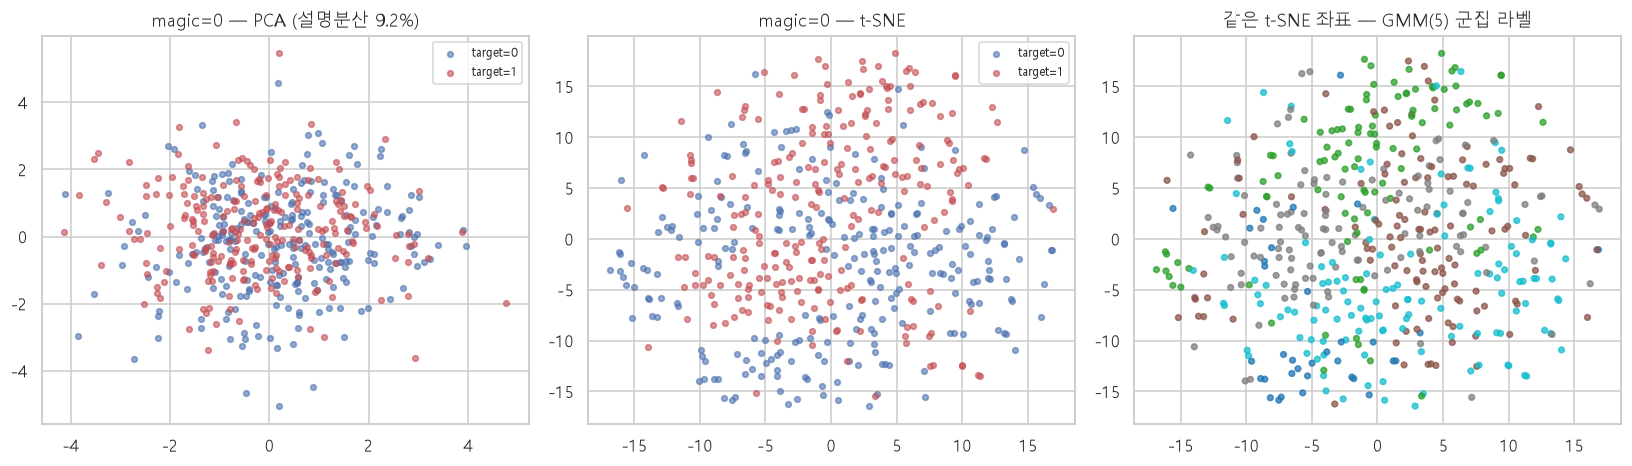

GMM 군집 × target 교차표:
target   0   1
GMM 군집        
0       29   6
1       39  68
2       71  53
3       53  66
4       68  59

군집별 target=1 비율: {0: 0.171, 1: 0.636, 2: 0.427, 3: 0.555, 4: 0.465}


In [11]:
from sklearn.manifold import TSNE

VIS_MAGIC = 0
idx = group_idx[VIS_MAGIC]
cols = np.where(useful_mask[VIS_MAGIC])[0]
Xg = StandardScaler().fit_transform(X[np.ix_(idx, cols)])
yg = y[idx]

pca2 = PCA(n_components=2, random_state=0).fit_transform(Xg)
tsne2 = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(Xg)
gmm5 = GaussianMixture(n_components=5, random_state=0, max_iter=1000).fit(Xg)
labels5 = gmm5.predict(Xg)      # baseline 이 쓰는 것과 같은 GMM 군집 라벨

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, emb, title in zip(
    axes[:2], (pca2, tsne2), (f"PCA (설명분산 {PCA(n_components=2).fit(Xg).explained_variance_ratio_.sum():.1%})", "t-SNE")
):
    for cls, color in zip((0, 1), ("#4c72b0", "#c44e52")):
        sel = yg == cls
        ax.scatter(emb[sel, 0], emb[sel, 1], s=14, alpha=0.6, c=color, label=f"target={cls}")
    ax.set_title(f"magic={VIS_MAGIC} — {title}")
    ax.legend(fontsize=8)

# 같은 t-SNE 좌표를 GMM 군집 라벨로 다시 칠한다 (좌표는 그대로, 색만 바뀜)
sc = axes[2].scatter(tsne2[:, 0], tsne2[:, 1], s=14, alpha=0.75, c=labels5, cmap="tab10")
axes[2].set_title("같은 t-SNE 좌표 — GMM(5) 군집 라벨")
plt.tight_layout()
plt.show()

# 교차표: 군집마다 target 비율이 다르면 군집 라벨에 분류 정보가 있다는 뜻
crosstab = pd.crosstab(labels5, yg)
crosstab.index.name = "GMM 군집"
crosstab.columns.name = "target"
print("GMM 군집 × target 교차표:")
print(crosstab.to_string())
print(f"\n군집별 target=1 비율: {(crosstab[1] / crosstab.sum(axis=1)).round(3).to_dict()}")

교차표를 보면 군집마다 target=1 비율이 0.17 ~ 0.64 로 크게 다르다.
하지만 **그룹 하나의 결과이므로 우연일 수 있다.** 통계 검정으로 확인하자.

**원리 — 카이제곱 독립성 검정**
"GMM 군집과 target 이 서로 **무관하다**"를 귀무가설로 놓고,
무관하다면 나왔을 기대 빈도와 실제 빈도의 차이를 잰다.
**p-value 가 작으면** 귀무가설을 기각 = 연관이 있다.

**원리 — 왜 p-value 분포를 보나?**
귀무가설이 참이면 p-value 는 **0~1 사이 균등분포**를 따른다.
따라서 80개 그룹을 검정했을 때 **p < 0.05 인 그룹이 약 5%(4개)** 여야 정상이다.
그보다 훨씬 많이 나오면 연관이 실재한다는 뜻이다.
(이렇게 **여러 번 검정한 결과를 모아서 보는 것**이 단일 p-value 보다 훨씬 신뢰할 만하다.)

**용어 — Cramér's V** : 연관의 **세기**를 0~1 로 재는 지표.
p-value 는 "연관이 있나 없나"만 답하고 세기는 말해 주지 않으므로 같이 본다.

**기대 결과** — p < 0.05 비율이 5% 를 크게 넘어야 한다.

chi2:   0%|          | 0/80 [00:00<?, ?it/s]

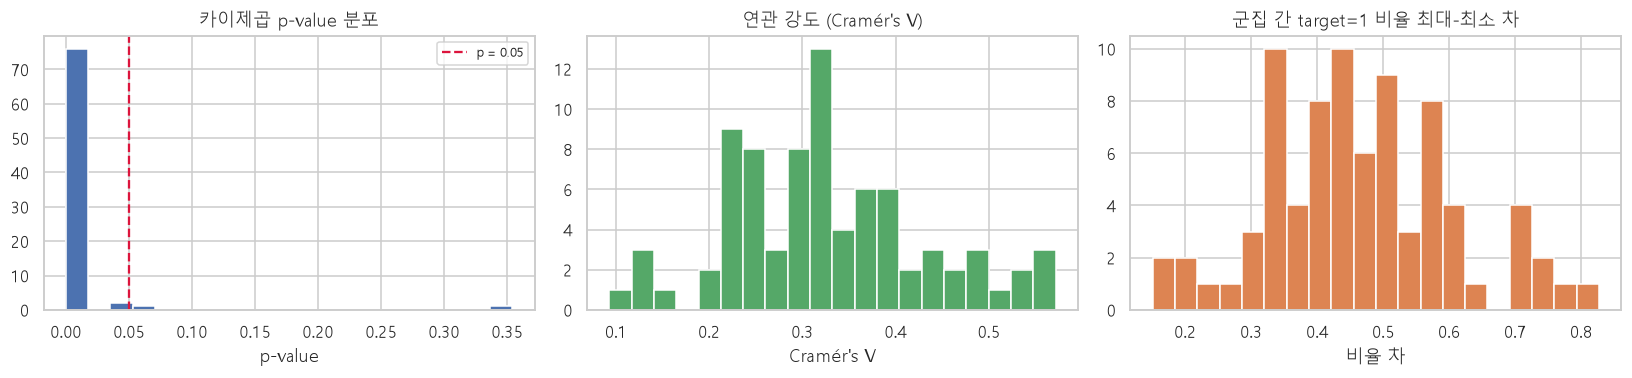

80개 그룹 중 p < 0.05: 78개 (97.5%)
  (귀무가설이 참이라면 5% 근처여야 한다)
p < 0.001: 75개
Cramér's V 평균 0.327, target 비율 차 평균 0.466


In [12]:
from scipy import stats

CHI_MAGICS = list(range(80))
pvals, cramers_v, ratio_spread = [], [], []

for m in tqdm(CHI_MAGICS, desc="chi2"):
    idx = group_idx[m]
    cols = np.where(useful_mask[m])[0]
    Xg = StandardScaler().fit_transform(X[np.ix_(idx, cols)])
    yg = y[idx]
    labels = GaussianMixture(n_components=5, random_state=0, max_iter=1000).fit_predict(Xg)
    table = pd.crosstab(labels, yg).to_numpy()          # 5 x 2 분할표
    chi2, p, dof, _ = stats.chi2_contingency(table)
    pvals.append(p)
    # Cramér's V = sqrt(chi2 / (N * (min(행,열) - 1)))
    cramers_v.append(np.sqrt(chi2 / (table.sum() * (min(table.shape) - 1))))
    rates = table[:, 1] / table.sum(axis=1)
    ratio_spread.append(rates.max() - rates.min())

pvals = np.array(pvals)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(pvals, bins=20, color="#4c72b0")
axes[0].axvline(0.05, color="crimson", ls="--", label="p = 0.05")
axes[0].set_title("카이제곱 p-value 분포")
axes[0].set_xlabel("p-value")
axes[0].legend(fontsize=8)

axes[1].hist(cramers_v, bins=20, color="#55a868")
axes[1].set_title("연관 강도 (Cramér's V)")
axes[1].set_xlabel("Cramér's V")

axes[2].hist(ratio_spread, bins=20, color="#dd8452")
axes[2].set_title("군집 간 target=1 비율 최대-최소 차")
axes[2].set_xlabel("비율 차")
plt.tight_layout()
plt.show()

print(f"{len(CHI_MAGICS)}개 그룹 중 p < 0.05: {(pvals < 0.05).sum()}개 ({(pvals < 0.05).mean():.1%})")
print(f"  (귀무가설이 참이라면 5% 근처여야 한다)")
print(f"p < 0.001: {(pvals < 0.001).sum()}개")
print(f"Cramér's V 평균 {np.mean(cramers_v):.3f}, target 비율 차 평균 {np.mean(ratio_spread):.3f}")

> **관찰 6.** 80개 그룹 중 **78개(97.5%)에서 p < 0.05**. 귀무가설이 참이라면 5% 여야 하는데
> 97.5% 가 나왔으니 **연관은 압도적으로 실재한다.** Cramér's V 평균 0.327 로 세기도 무시할 수준이 아니다.
>
> 반면 2차원 투영으로는 두 클래스가 전혀 분리되지 않는다 — 40차원 전체를 써야 신호가 나온다.
>
> **두 결과를 합치면 5절의 해석이 완성된다.**
> 밀도 모형으로서의 k=5 는 BIC 가 지지하지 않지만,
> **분류에 쓸 좌표로서의 k=5 는 실제로 target 정보를 담고 있다.**
> baseline 이 GMM 소속 확률을 파생 피처로 넣고 CV 를 이 라벨로 stratify 하는 근거다.

## 7. 요약

| # | 질문 | 결론 |
|---|---|---|
| 1 | train/test 구조 일치? | 유효 피처 집합 Jaccard = 1.0 (512/512 완전 일치) — transductive 접근이 정당하다 |
| 2 | 그룹 간 공통 구조? | 공유 피처 수 6.17 = 무작위 기댓값 6.17 — **공유 구조 없음** |
| 3 | 난이도 결정 요인 | 유효 피처 수와 **무관**(corr +0.09). 그룹별 AUC 편차의 **83%가 측정 오차** |
| 4 | 중복 피처? | 공분산 full rank — **유효 피처 ≈ informative 차원**, 차원 축소는 정보 손실 |
| 5 | 클래스당 군집 수 | BIC 는 k=1 — 256개 표본으로는 **식별 불가**. GMM(5)는 밀도 추정기가 아니라 좌표 생성기 |
| 6 | GMM 군집 ↔ target | 97.5% 그룹에서 유의 — 군집 라벨에 실제 분류 정보가 있다 |

### 가설이 틀린 두 곳

- ❌ "유효 피처가 많을수록 어렵다" → 상관 +0.09, 무관
- ❌ "BIC 가 다봉 구조를 잡아낼 것이다" → full/diag 모두 k=1

**두 번째 기각이 이 노트북에서 가장 값진 결과다.** GMM 을 "군집을 찾는 도구"로 보면 k=5 는 과해 보이지만,
"좌표를 만드는 도구"로 보면 k 는 AUC 로 정할 하이퍼파라미터다.
**틀린 가설이 baseline 을 더 정확히 이해하게 만들었다.**

### 이 노트북에서 배운 분석 습관 3가지

1. **관측값은 항상 기준선과 비교한다** — 공유 피처 6.17 은 기댓값 6.17 과 비교했을 때만 의미가 있었다
2. **차이를 보면 먼저 측정 오차를 의심한다** — 그룹 AUC 편차의 83%가 잡음이었다
3. **평가 기준은 목적에 맞춰 고른다** — 밀도 추정이면 BIC, 분류면 AUC

### 직접 해보기

- 3절의 `group_qda_auc` 에서 `seed` 를 0이 아닌 값으로 바꿔 512개 그룹을 다시 재 보라.
  "가장 어려운 그룹"이 magic=92 그대로인가? 바뀐다면 그것이 곧 잡음이라는 증거다
- 5절에서 PCA 차원을 10 대신 3으로 줄이면 BIC 가 k>1 을 고르는가?
  (파라미터 수가 줄어 벌점이 작아지므로 결과가 달라질 수 있다)
- 6절의 카이제곱 검정을 **GMM 대신 KMeans** 군집으로 바꿔도 같은 결론이 나오는가?

### 다음 노트북

[03_feature_engineering](03_feature_engineering.ipynb) 에서 여기서 세운 가설들을
**실제 AUC 로 하나씩 검증**한다. 차원 축소는 정말 손해인가? k=5 가 정말 최적인가?